# Variables antitéticas

Las variables antitéticas son una técnica de reducción de varianza que aprovecha la correlación negativa entre pares de variables aleatorias. Consiste en generar muestras pareadas 
$(U,1−U)$ en lugar de muestras independientes, de modo que la variabilidad del estimador se reduce.

La varianza de este estimador es $\frac{\sigma^2}{N}$, donde $\sigma^2=Var(f(U))$.

Con variables antitéticas, usamos pares $(U_i,1−U_i)$ y definimos el estimador:

$$
\hat{\theta}_{anti}=\frac{1}{2N}\sum_{i=1}^{N}[f(U_i)+f(1−U_i)].
$$

La varianza de la media de cada par es:
$$ 
Var\left(\frac{f(U)+f(1−U)}{2}\right)= \frac{1}{4}[Var(f(U))+Var(f(1−U))+2Cov(f(U),f(1−U))].
$$

Como $f(U)$ y $f(1−U)$ tienen la misma varianza $\sigma^2$, la varianza del par es:
$$
\frac{1}{2}\sigma^2+\frac{1}{2}Cov(f(U),f(1−U)).
$$
Si la covarianza es negativa (lo cual ocurre para funciones monótonas), la varianza del estimador antitético es menor que $\frac{\sigma^2}{n}$, logrando así una reducción de varianza.

In [ ]:
#Librerías a usar
import numpy as np
import matplotlib.pyplot as plt

## Integral a resolver por MonteCarlo
Queremos estimar la integral de la función $f(x)=\frac{1}{1+x}$, donde $\theta=\int_{0}^{1}f(x)dx$ mediante Monte Carlo, el estimador estándar es $\hat{\theta}=\frac{1}{N}\sum_{i=1}^{N} f(U_{i})$ con $U\sim$ Uniforme $(0,1)$.

La función $f(x)=\frac{1}{1+x}$ es estrictamente decreciente en $[0,1]$, por lo que $f(U)$ y $f(1−U)$ están correlacionadas negativamente. La técnica antitética es especialmente efectiva aquí.

In [2]:
# ------------------------------------------------------------
# 1. Definir la función integrando
# ------------------------------------------------------------
def f(x):
    """Función a integrar: f(x) = 1/(1+x)."""
    return 1.0 / (1.0 + x)

# Valor exacto de la integral (conocido analíticamente)
exact_value = np.log(2)   # ≈ 0.69314718056

## Paramétros

In [5]:
# ------------------------------------------------------------
# 2. Parámetros de la simulación
# ------------------------------------------------------------
N_values = [10, 100, 1000, 10000, 100000]  # diferentes tamaños de muestra

# Listas para almacenar resultados
estimates_simple = []
estimates_anti = []
errors_simple = []
errors_anti = []

## Bucle de simulación

In [6]:
# ------------------------------------------------------------
# 3. Bucle sobre diferentes N para estudiar convergencia
# ------------------------------------------------------------
for N in N_values:
    # --- 3a. Monte Carlo Simple ---
    U = np.random.uniform(0, 1, N)          # N números uniformes
    f_simple = f(U)                         # evaluar f en cada uno
    est_simple = np.mean(f_simple)          # estimador
    var_simple = np.var(f_simple, ddof=1) / N   # varianza estimada del estimador
    error_simple = np.abs(est_simple - exact_value)

    # --- 3b. Variables Antitéticas ---
    U_anti = np.random.uniform(0, 1, N)     # N uniformes (cada uno forma un par)
    f1 = f(U_anti)                          # f(U)
    f2 = f(1 - U_anti)                      # f(1-U)
    # Promedio de cada par: (f(U)+f(1-U))/2
    pair_means = (f1 + f2) / 2.0
    est_anti = np.mean(pair_means)          # estimador antitético
    var_anti = np.var(pair_means, ddof=1) / N   # varianza del estimador (basada en N pares)
    error_anti = np.abs(est_anti - exact_value)

    # Almacenar resultados
    estimates_simple.append(est_simple)
    estimates_anti.append(est_anti)
    errors_simple.append(error_simple)
    errors_anti.append(error_anti)

    # Mostrar resultados en consola
    print(f"N = {N:6d} | Simple: {est_simple:.6f} (error = {error_simple:.4e}) | "
          f"Anti: {est_anti:.6f} (error = {error_anti:.4e})")

N =     10 | Simple: 0.682911 (error = 1.0236e-02) | Anti: 0.689980 (error = 3.1675e-03)
N =    100 | Simple: 0.713503 (error = 2.0356e-02) | Anti: 0.688992 (error = 4.1554e-03)
N =   1000 | Simple: 0.694197 (error = 1.0495e-03) | Anti: 0.693551 (error = 4.0339e-04)
N =  10000 | Simple: 0.691650 (error = 1.4968e-03) | Anti: 0.693262 (error = 1.1471e-04)
N = 100000 | Simple: 0.693858 (error = 7.1084e-04) | Anti: 0.693147 (error = 2.0275e-07)


## Gráfica de error

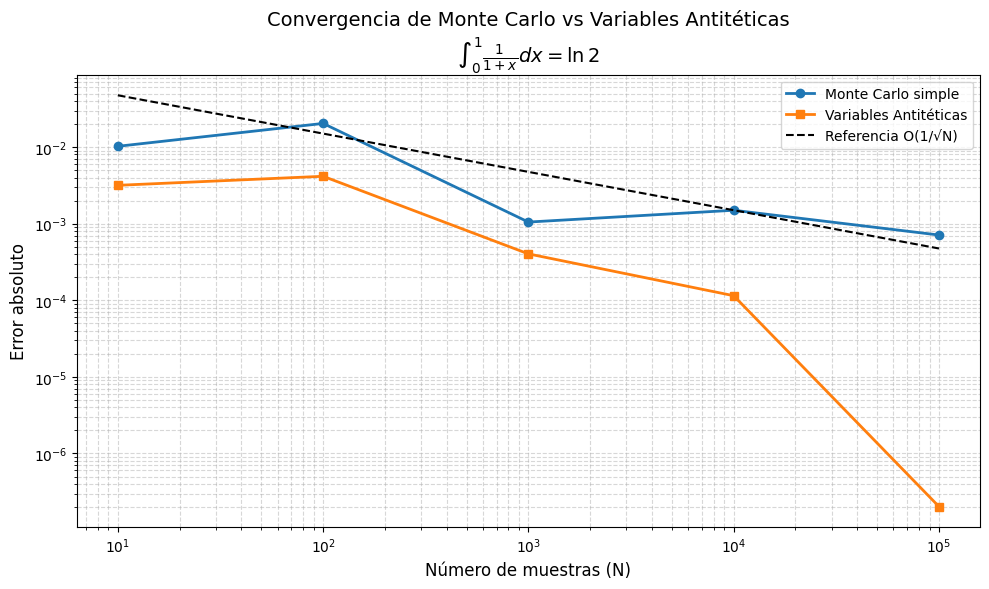

In [7]:
# ------------------------------------------------------------
# 4. Gráfica de convergencia (error vs N) en escala log-log
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Errores absolutos
plt.loglog(N_values, errors_simple, 'o-', label='Monte Carlo simple', linewidth=2)
plt.loglog(N_values, errors_anti, 's-', label='Variables Antitéticas', linewidth=2)

# Línea de referencia: error ∝ 1/√N (con constante ajustada para visualización)
ref_N = np.array(N_values)
ref_error = 0.15 / np.sqrt(ref_N)   # constante elegida para superponer
plt.loglog(ref_N, ref_error, 'k--', label='Referencia O(1/√N)')

plt.xlabel('Número de muestras (N)', fontsize=12)
plt.ylabel('Error absoluto', fontsize=12)
plt.title('Convergencia de Monte Carlo vs Variables Antitéticas\n'
          r'$\int_0^1 \frac{1}{1+x} dx = \ln 2$', fontsize=14)
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Comparativa

In [4]:
# ------------------------------------------------------------
# 5. Mostrar reducción de varianza en términos de varianza estimada
# ------------------------------------------------------------
print("\n--- Varianza estimada del estimador (último N) ---")
print(f"Simple: {var_simple:.6e}")
print(f"Anti:   {var_anti:.6e}")
print(f"Reducción: { (var_simple - var_anti)/var_simple * 100:.2f} %")


--- Varianza estimada del estimador (último N) ---
Simple: 1.965174e-07
Anti:   5.947839e-09
Reducción: 96.97 %
